In [2]:
import warnings
warnings.filterwarnings("ignore")

In [50]:
import sqlite3

import numpy as np
import pandas as pd
import seaborn as sns

from collections import Counter
import re

import matplotlib.pyplot as plt
from natasha import (
    Segmenter,
    MorphVocab,
    NewsMorphTagger,
    NewsSyntaxParser,
    NewsEmbedding,
    Doc
)
from pymorphy3 import MorphAnalyzer

In [90]:
DB_FILE = "articles.sqlite"

conn = sqlite3.connect(DB_FILE)

df = pd.read_sql_query("SELECT * FROM articles;", conn)

conn.close()

In [91]:
RANDOM_STATE = 42

In [92]:
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df = df["description"]

In [93]:
df[0]

'Доля Intel впервые достигла 1%.\n\nJon Peddie Research опубликовала отчёт о рынке дискретных видеокарт (AIB) за третий квартал 2025 года.\n\nДоля AMD увеличилась на 0,8% и составила 7%, что пока ниже показателей первого квартала 2025 года. Intel прибавила 0,4% и впервые достигла отметки в 1% рынка. Рост конкурентов привёл к снижению доли NVIDIA на 1.2% до 92%, однако компания по-прежнему сохраняет доминирующее положение.\n\nСогласно данным, общий объём рынка достиг $8,8 млрд, а поставки выросли до 12 млн единиц — на 2,8% больше по сравнению с предыдущим кварталом, — что ниже средних значений десятилетнего периода для этого квартала (11,4%). JPR это связывает с рекордными закупками во втором квартале, которые могли быть связаны с повышенным спросом на фоне ожидаемого увеличения тарифов, что частично сократило объёмы закупок в третьем квартале.\n\nАналитики ожидают возможный рост активности в четвёртом квартале. Причина — грядущее повышение цен на видеокарты, о котором уже сообщают отра

In [94]:
def clean_txt(sentence: str):
    sentence = sentence.replace("\n\n", " ").replace("\xa0", " ") 

    return sentence

In [103]:
def split_into_sentences(text):
    """
    Разбивает текст на предложения, учитывая различные разделители.
    """ 
    sentences = []
    
    # разбиваем по основным разделителям
    parts = re.split(r'([.!?])\s+', text)
    
    # Собираем предложения обратно с учетом разделителей
    i = 0
    while i < len(parts):
        if i + 1 < len(parts) and parts[i+1] in ['.', '!', '?']:
            sentence = parts[i] + parts[i+1]
            sentences.append(sentence.strip())
            i += 2
        else:
            if parts[i].strip():
                sentences.append(parts[i].strip())
            i += 1
    
    # Дополнительная проверка: если остались части без разделителей
    if parts and len(parts) % 2 == 1 and parts[-1].strip():
        sentences.append(parts[-1].strip())
    
    # Фильтруем пустые предложения и слишком короткие
    sentences = [s for s in sentences if len(s.split()) >= 3]
    
    return sentences

In [96]:
def load_texts_from_dataframe(df):
    """
    Загружает тексты из DataFrame и разбивает на предложения.
    """
    all_sentences = []
    
    for idx, text in df.items():
        sentences = split_into_sentences(clean_txt(text))
        all_sentences.extend(sentences)
    
    return all_sentences

In [97]:
texts = load_texts_from_dataframe(df)

In [98]:
segmenter = Segmenter()
embedding = NewsEmbedding()
morph_vocab = MorphVocab()
morph_tagger = NewsMorphTagger(embedding)
syntax_parser = NewsSyntaxParser(embedding)

morph = MorphAnalyzer()

In [99]:
def parse_sentence(sentence, segmenter, morph_tagger, syntax_parser):
    """
    Выполняет синтаксический разбор предложения и выделяет подлежащее и сказуемое.
    """
    try:
        doc = Doc(sentence)
        doc.segment(segmenter)
        doc.tag_morph(morph_tagger)
        doc.parse_syntax(syntax_parser)
        
        subjects = []
        predicates = []
        
        if not doc.sents:
            return None, None
        
        for token in doc.sents[0].tokens:
            # Сохраняем исходную форму через morph_vocab
            token.lemmatize(morph_vocab)
            
            # Ищем подлежащее (nsubj - номинативный субъект)
            if token.rel in ['nsubj', 'nsubj:pass']:
                subjects.append(token.lemma.lower())
            
            # Ищем сказуемое (root - корень предложения)
            if token.rel == 'root':
                predicates.append(token.lemma.lower())

        subject = subjects[0] if subjects else None
        predicate = predicates[0] if predicates else None
        
        return subject, predicate
        
    except Exception as e:
        return None, None


In [100]:
def build_cooccurrence_dependencies(texts, segmenter, morph_tagger, syntax_parser):
    """
    Строит зависимости совместных употреблений подлежащих и сказуемых.
    """
    cooccurrences = []
    total = len(texts)
    
    for i, sentence in enumerate(texts):
        subject, predicate = parse_sentence(
            sentence, segmenter, morph_tagger, syntax_parser
        )
        
        if subject and predicate:
            cooccurrences.append((subject, predicate))
    
    return Counter(cooccurrences)

In [101]:
def visualize_results(counter):
    plt.figure(figsize=(14, 6))
    
    # топ-20 наиболее частых сочетаний
    most_common_pairs = counter.most_common(20)
    pairs = [f"{p[0]}→{p[1]}" for p, _ in most_common_pairs]
    counts = [c for _, c in most_common_pairs]
    
    bars = plt.bar(range(len(pairs)), counts, color='skyblue', edgecolor='navy', alpha=0.7)
    
    # Настройка графика
    plt.xticks(range(len(pairs)), pairs, rotation=45, ha='right', fontsize=9)
    plt.ylabel('Частота встречаемости', fontsize=12, fontweight='bold')
    plt.xlabel('Пары подлежащее-сказуемое', fontsize=12, fontweight='bold')
    plt.title('Топ-20 пар подлежащее-сказуемое', fontsize=14, fontweight='bold', pad=20)
    
    # Добавляем значения на столбцы
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')
    

    plt.grid(axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

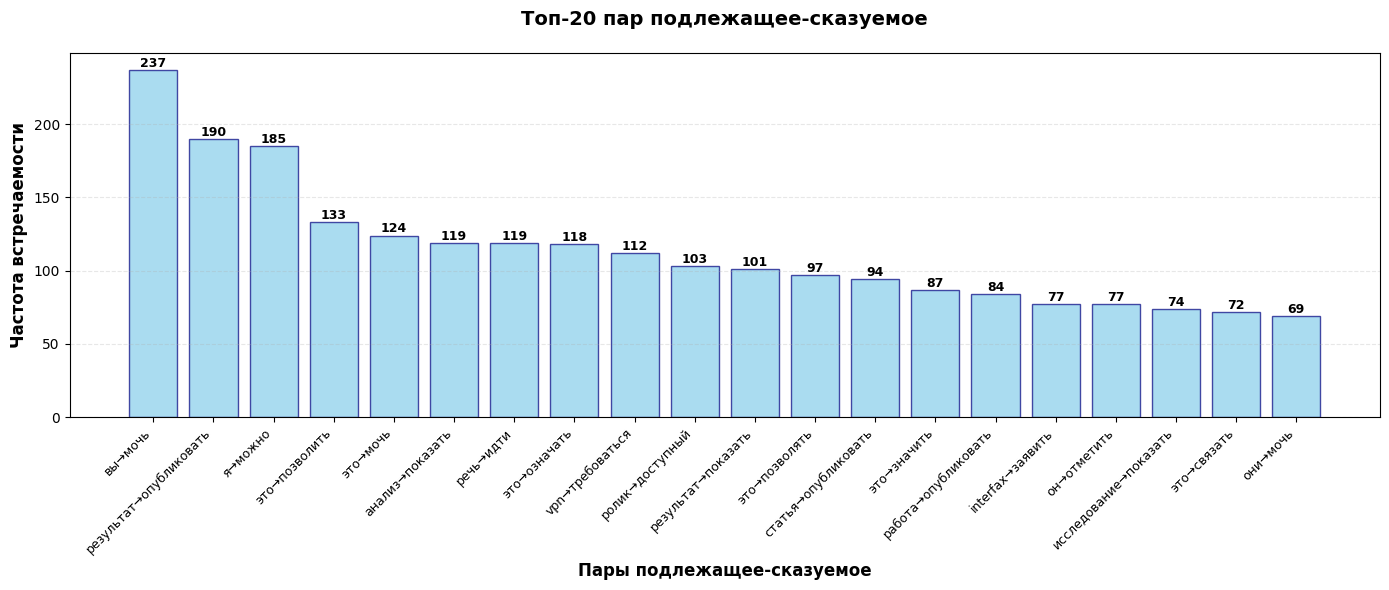

In [102]:
cooccurrences = build_cooccurrence_dependencies(
    texts,
    segmenter,
    morph_tagger,
    syntax_parser
)
total_pairs = sum(cooccurrences.values())

visualize_results(cooccurrences)